<a href="https://colab.research.google.com/github/annb-lab/NLStradamus/blob/main/NLStradamus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**This is a ChatGPT version of the most basic use case of NLStradamus**

We recommend using the webserver when possible as this code is not maintained and cannot handle the different models that NLStradamus has.

Our webserver was hacked recently and this notebook was created to help serve the need of NLS predictions in the meantime.

In [ ]:
# @title
import numpy as np


def posterior_probabilities(
    sequence,
    emission,
    transmat,
    startprob,
    amino_acids="LSKIETNDVAGRFPQYHMCW",
):
    """
    Calculate posterior P(state_t | entire sequence)
    using scaled forward-backward probabilities.

    Parameters
    ----------
    sequence : str
        Protein amino-acid sequence.

    emission : ndarray, shape (n_states, n_amino_acids)
        emission[state, amino_acid]

    transmat : ndarray, shape (n_states, n_states)
        transmat[from_state, to_state]

    startprob : ndarray, shape (n_states,)
        Initial state probabilities.

    amino_acids : str
        Order of amino-acid columns in emission.

    Returns
    -------
    posterior : ndarray, shape (sequence_length, n_states)
        Posterior probability for each state at each position.

    alpha : ndarray
        Scaled forward probabilities.

    beta : ndarray
        Scaled backward probabilities.

    scales : ndarray
        Scaling factors used at each position.
    """

    sequence = sequence.upper()

    aa_to_index = {
        aa: i for i, aa in enumerate(amino_acids)
    }

    # Check sequence
    unknown = set(sequence) - set(amino_acids)
    if unknown:
        raise ValueError(
            f"Unknown amino acids in sequence: {unknown}"
        )

    observations = np.array(
        [aa_to_index[aa] for aa in sequence],
        dtype=int
    )

    n_positions = len(sequence)
    n_states = transmat.shape[0]

    # ---------------------------------------------------------
    # Sanity checks
    # ---------------------------------------------------------

    if emission.shape != (n_states, len(amino_acids)):
        raise ValueError(
            f"Emission matrix has shape {emission.shape}, "
            f"expected {(n_states, len(amino_acids))}"
        )

    if transmat.shape != (n_states, n_states):
        raise ValueError("Transition matrix has incorrect shape.")

    if len(startprob) != n_states:
        raise ValueError("startprob has incorrect length.")

    # ---------------------------------------------------------
    # Forward pass with scaling
    # ---------------------------------------------------------

    alpha = np.zeros((n_positions, n_states))
    scales = np.zeros(n_positions)

    # First position
    alpha[0] = (
        startprob *
        emission[:, observations[0]]
    )

    scales[0] = alpha[0].sum()

    if scales[0] <= 0:
        raise ValueError("Zero probability at first sequence position.")

    alpha[0] /= scales[0]

    # Remaining positions
    for t in range(1, n_positions):

        alpha[t] = (
            alpha[t - 1] @ transmat
        ) * emission[:, observations[t]]

        scales[t] = alpha[t].sum()

        if scales[t] <= 0:
            raise ValueError(
                f"Zero probability at sequence position {t}."
            )

        alpha[t] /= scales[t]

    # ---------------------------------------------------------
    # Backward pass using the same scaling factors
    # ---------------------------------------------------------

    beta = np.zeros((n_positions, n_states))

    # At the final position
    beta[-1] = 1.0

    for t in range(n_positions - 2, -1, -1):

        beta[t] = (
            transmat @ (
                emission[:, observations[t + 1]]
                * beta[t + 1]
            )
        )

        # IMPORTANT:
        # Use the same scale that was applied to alpha[t + 1].
        beta[t] /= scales[t + 1]

    # ---------------------------------------------------------
    # Posterior probabilities
    # ---------------------------------------------------------

    posterior = alpha * beta

    # Normalize each position.
    posterior /= posterior.sum(axis=1, keepdims=True)

    return posterior, alpha, beta, scales

In [ ]:
# @title
emission = np.array([
    [
        0.0950300339227636,  # L
        0.0898291379118776,  # S
        0.0734833177642526,  # K
        0.0655547462377008,  # I
        0.0654254611397116,  # E
        0.0616309263671642,  # N
        0.0591563341467664,  # T
        0.0585263693589517,  # D
        0.0556015083490053,  # V
        0.0549499388896433,  # A
        0.0497648177182998,  # G
        0.0443626210376004,  # R
        0.0441551476044877,  # F
        0.0437563185090993,  # P
        0.0395581536030419,  # Q
        0.0337842193992118,  # Y
        0.0216513102033034,  # H
        0.0208056416313105,  # M
        0.0125821491915738,  # C
        0.0103918470142344,  # W
    ],
    [
        0.0548387096774,      # L
        0.0677419354839,      # S
        0.270967741935,       # K
        0.041935483871,       # I
        0.041935483871,       # E
        0.041935483871,       # N
        0.0306451612903,      # T
        0.0258064516129,      # D
        0.0290322580645,      # V
        0.0516129032258,      # A
        0.0564516129032,      # G
        0.133870967742,       # R
        0.0209677419355,      # F
        0.0564516129032,      # P
        0.0225806451613,      # Q
        0.0112903225806,      # Y
        0.0225806451613,      # H
        0.0112903225806,      # M
        0.00161290322581,     # C
        0.00645161290323,     # W
    ]
], dtype=np.float64)


transmat = np.array([
    [0.9973625365518032, 0.00263746344819678],
    [0.0741935483870968, 0.9258064516129032]
], dtype=np.float64)


# Exactly what the Perl code does:
startprob = np.array([
    transmat[0, 0],
    1.0 - transmat[0, 0]
], dtype=np.float64)

In [ ]:
import re

def clean_sequence(seq):
    seq = seq.upper().rstrip("*")
    seq = re.sub(r"[^ACDEFGHIKLMNPQRSTVWY]", "", seq)
    return seq

sequence = "MEGSTGFDGDATTFFAPDAVFGDRVRRFQEFLDTFTSYRDSVRSIQVYNSNNAANYNDDQDDADERDLLGDDDGDDLEKEKKAASSTSLNILPHRIIISLDDLREFDRSFWSGILVEPAYFIPPAEKALTDLADSMDDVPHPNASAVSSRHPWKLSFKGSFGAHALSPRTLTAQHLNKLVSVEGIVTKTSLVRPKLIRSVHYAAKTGRFHYRDYTDATTTLTTRIPTPAIYPTEDTEGNKLTTEYGYSTFIDHQRITVQEMPEMAPAGQLPRSIDVILDDDLVDKTKPGDRVNVVGVFKSLGAGGMNQSNSNTLIGFKTLILGNTVYPLHARSTGVAARQMLTDFDIRNINKLSKKKDIFDILSQSLAPSIYGHDHIKKAILLMLMGGVEKNLENGSHLRGDINILMVGDPSTAKSQLLRFVLNTASLAIATTGRGSSGVGLTAAVTTDRETGERRLEAGAMVLADRGVVCIDEFDKMTDVDRVAIHEVMEQQTVTIAKAGIHTTLNARCSVIAAANPVFGQYDVNRDPHQNIALPDSLLSRFDLLFVVTDDINEIRDRSISEHVLRTHRYLPPGYLEGEPVRERLNLSLAVGEDADINPEEHSNSGAGVENEGEDDEDHVFEKFNPLLQAGAKLAKNKGNYNGTEIPKLVTIPFLRKYVQYAKERVIPQLTQEAINVIVKNYTDLRNDDNTKKSPITARTLETLIRLATAHAKVRLSKTVNKVDAKVAANLLRFALLGEDIGNDIDEEESEYEEALSKRSPQKSPKKRQRVRQPASNSGSPIKSTPRRSTASSVNATPSSARRILRFQDDEQNAGEDDNDIMSPLPADEEAELQRRLQLGLRVSPRRREHLHAPEEGSSGPLTEVGTPRLPNVSSAGQDDEQQQSVISFDNVEPGTISTGRLSLISGIIARLMQTEIFEEESYPVASLFERINEELPEEEKFSAQEYLAGLKIMSDRNNLMVADDKVWRV" # @param {"type":"string","placeholder":"MEGSTGFDGDATTFFAPDAVFGDRVRRFQEFLDTFTSYRDSVRSIQVYNSNNAANYNDDQDDADERDLLGDDDGDDLEKEKKAASSTSLNILPHRIIISLDDLREFDRSFWSGILVEPAYFIPPAEKALTDLADSMDDVPHPNASAVSSRHPWKLSFKGSFGAHALSPRTLTAQHLNKLVSVEGIVTKTSLVRPKLIRSVHYAAKTGRFHYRDYTDATTTLTTRIPTPAIYPTEDTEGNKLTTEYGYSTFIDHQRITVQEMPEMAPAGQLPRSIDVILDDDLVDKTKPGDRVNVVGVFKSLGAGGMNQSNSNTLIGFKTLILGNTVYPLHARSTGVAARQMLTDFDIRNINKLSKKKDIFDILSQSLAPSIYGHDHIKKAILLMLMGGVEKNLENGSHLRGDINILMVGDPSTAKSQLLRFVLNTASLAIATTGRGSSGVGLTAAVTTDRETGERRLEAGAMVLADRGVVCIDEFDKMTDVDRVAIHEVMEQQTVTIAKAGIHTTLNARCSVIAAANPVFGQYDVNRDPHQNIALPDSLLSRFDLLFVVTDDINEIRDRSISEHVLRTHRYLPPGYLEGEPVRERLNLSLAVGEDADINPEEHSNSGAGVENEGEDDEDHVFEKFNPLLQAGAKLAKNKGNYNGTEIPKLVTIPFLRKYVQYAKERVIPQLTQEAINVIVKNYTDLRNDDNTKKSPITARTLETLIRLATAHAKVRLSKTVNKVDAKVAANLLRFALLGEDIGNDIDEEESEYEEALSKRSPQKSPKKRQRVRQPASNSGSPIKSTPRRSTASSVNATPSSARRILRFQDDEQNAGEDDNDIMSPLPADEEAELQRRLQLGLRVSPRRREHLHAPEEGSSGPLTEVGTPRLPNVSSAGQDDEQQQSVISFDNVEPGTISTGRLSLISGIIARLMQTEIFEEESYPVASLFERINEELPEEEKFSAQEYLAGLKIMSDRNNLMVADDKVWRV"}
sequence = clean_sequence(sequence)

posterior, alpha, beta, scales = posterior_probabilities(
    sequence,
    emission,
    transmat,
    startprob
)

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt


def plot_state1_posterior(sequence, posterior, threshold=0.6):
    """
    Plot State 1 posterior probability along a protein sequence.

    Parameters
    ----------
    sequence : str
        Protein amino-acid sequence.

    posterior : ndarray, shape (len(sequence), n_states)
        Posterior probabilities from posterior_probabilities().

    threshold : float
        Probability threshold for highlighting State 1.
    """

    positions = np.arange(1, len(sequence) + 1)
    state1 = posterior[:, 1]

    fig, (ax1, ax2) = plt.subplots(
        2,
        1,
        figsize=(16, 5),
        sharex=True,
        gridspec_kw={"height_ratios": [4, 1]}
    )

    # ---------------------------------------------------------
    # Top: posterior probability
    # ---------------------------------------------------------

    ax1.plot(
        positions,
        state1,
        color="steelblue",
        linewidth=1.5,
        label="NLS posterior probability"
    )

    # Highlight regions above threshold
    ax1.fill_between(
        positions,
        threshold,
        state1,
        where=(state1 >= threshold),
        color="tomato",
        alpha=0.35,
        interpolate=True,
        #label=f"P(State 1) ≥ {threshold}"
    )

    # Threshold line
    ax1.axhline(
        threshold,
        color="tomato",
        linestyle="--",
        linewidth=1.2,
        label=f"Threshold = {threshold}"
    )

    ax1.set_ylabel("Posterior probability")
    ax1.set_ylim(0, 1)
    #ax1.set_title("NLS posterior probability")
    ax1.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    ax1.legend(
        loc="upper right",
        frameon=False
    )

    # ---------------------------------------------------------
    # Bottom: amino-acid sequence
    # ---------------------------------------------------------

    ax2.set_ylim(0, 1)
    ax2.set_yticks([])

    for i, (position, aa, probability) in enumerate(
        zip(positions, sequence, state1)
    ):
        color = "tomato" if probability >= threshold else "black"

        ax2.text(
            position,
            0.5,
            aa,
            ha="center",
            va="center",
            fontsize=8,
            color=color
        )

    ax2.set_xlabel("Protein position")

    # Put ticks at reasonable intervals
    tick_spacing = max(1, len(sequence) // 20)

    ax2.set_xticks(
        np.arange(1, len(sequence) + 1, tick_spacing)
    )

    plt.tight_layout()
    plt.show()

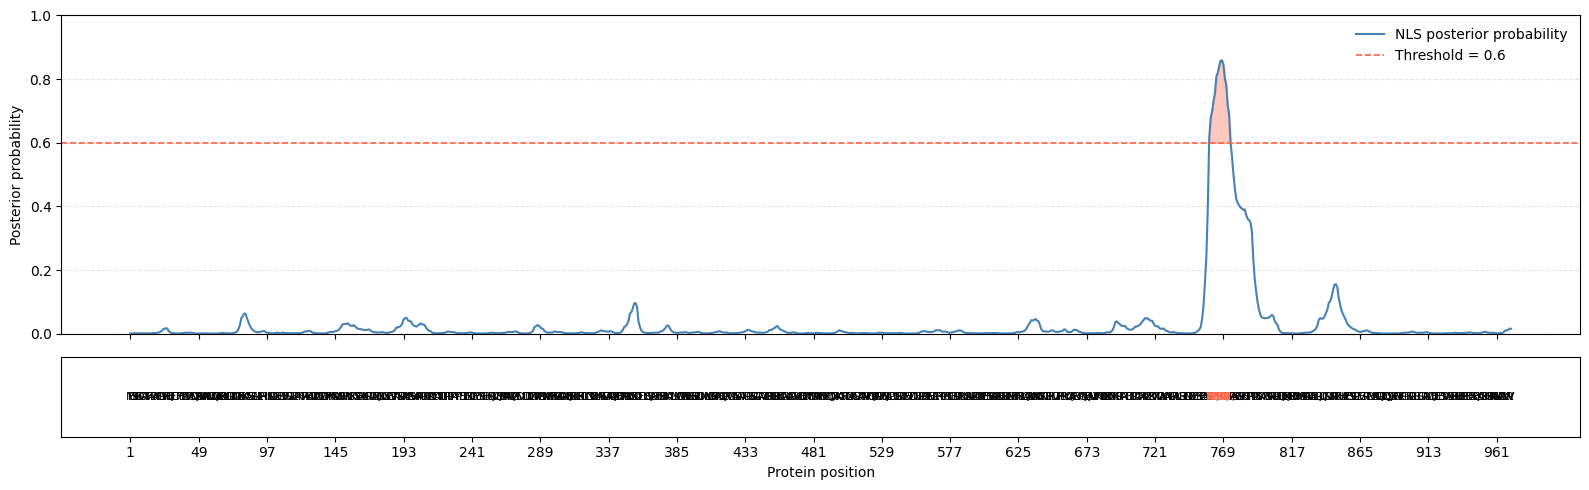

In [ ]:
threshold = 0.6 # @param {"type":"number","placeholder":"0.6"}
if not 0 <= threshold <= 1:
    raise ValueError("Threshold must be between 0 and 1")
plot_state1_posterior(
    sequence,
    posterior,
    threshold=threshold
)

In [ ]:
# @title
import numpy as np
import pandas as pd


def get_state1_segments(sequence, posterior, threshold=0.6):
    """
    Find contiguous State 1 regions where P(State 1 | sequence)
    is >= threshold.

    Returns
    -------
    pandas.DataFrame
        One row per contiguous segment.
    """

    state1 = posterior[:, 1]

    # True wherever probability meets/exceeds threshold
    above = state1 >= threshold

    segments = []

    in_segment = False

    for i, is_above in enumerate(above):

        # Start of a segment
        if is_above and not in_segment:
            start = i
            in_segment = True

        # End of a segment
        elif not is_above and in_segment:
            end = i - 1

            segment_probs = state1[start:end + 1]
            max_idx = start + np.argmax(segment_probs)

            segments.append({
                "start": start + 1,       # 1-based
                "end": end + 1,           # 1-based
                "length": end - start + 1,
                "sequence": sequence[start:end + 1],
                "max_probability": state1[max_idx],
                "max_position": max_idx + 1
            })

            in_segment = False

    # Handle a segment that reaches the end of the protein
    if in_segment:
        end = len(sequence) - 1

        segment_probs = state1[start:end + 1]
        max_idx = start + np.argmax(segment_probs)

        segments.append({
            "start": start + 1,
            "end": end + 1,
            "length": end - start + 1,
            "sequence": sequence[start:end + 1],
            "max_probability": state1[max_idx],
            "max_position": max_idx + 1
        })

    return pd.DataFrame(segments)

In [ ]:
# @title
segments = get_state1_segments(
    sequence,
    posterior,
    threshold=threshold
)

print(segments)

   start  end  length          sequence  max_probability  max_position
0    759  774      16  KRSPQKSPKKRQRVRQ         0.859059           768
